# 📊 LDH Adsorption – EDA & PCA Analysis
**Dataset:** Micropollutant adsorption trên vật liệu LDH (Layered Double Hydroxide)  
**Mục tiêu:** EDA → PCA compression → Feature engineering → Gradient Boosting (RR% & Qe mg/g)

---
### Cấu trúc notebook
1. Import & Load dữ liệu
2. Tiền xử lý & Chuẩn hóa
3. EDA tổng quan
4. EDA theo nhóm
5. PCA – Micropollutant features (Log Kow, MW, E, S, A, B, V)
6. PCA – Material texture features (BET, PV, APD, pHpzc)
7. Correlation analysis sau PCA
8. Model – Gradient Boosting (RR% & Qe)
9. Feature Importance

In [1]:
!pip install Boruta BorutaShap "scipy<1.12.0"
!pip install cubist
!pip install optuna

  Using cached cubist-1.2.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (6.1 kB)
Using cached cubist-1.2.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (594 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 20.8 MB/s eta 0:00:00


## 1. Import thư viện & Load dữ liệu

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

from boruta import BorutaPy
from BorutaShap import BorutaShap

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor' : '#F8F9FA',
    'axes.facecolor'   : '#FAFAFA',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'axes.titleweight' : 'bold',
    'axes.titlesize'   :  12,
})

SEED = 42
print('✅ Thư viện đã import xong')

✅ Thư viện đã import xong


In [4]:
# Load dữ liệu
FILE_PATH = '/content/drive/MyDrive/Green-X Project/Data/Data_Adsorption.xlsx'
df_raw = pd.read_excel(FILE_PATH, sheet_name=0, header=1)   # header nằm ở row 2

print(f'Shape gốc: {df_raw.shape}')
print(f'Cột: {df_raw.columns.tolist()}')

Shape gốc: (1343, 30)
Cột: ['Id', 'TP', 'Log Kow', 'MW g/mol', 'E', 'S', 'A', 'B', 'V', 'Metal(II) ', 'Metal(III)', 'Method', 'M(II)/(III)', 'TemH oC', 'HT hour', '2theta', 'd(003)', 'BET m2/g', 'PV cm3/g', 'APD nm', 'pHpzc', 'pH', 'Tem', 'Time h', 'AD g/L', 'Ci mg/L', 'Qt', 'Ce mg/L', 'Qe mg/g', 'RR %']


In [5]:
df_raw.head(5)

,Id,TP,Log Kow,MW g/mol,E,S,A,B,V,Metal(II),...,pHpzc,pH,Tem,Time h,AD g/L,Ci mg/L,Qt,Ce mg/L,Qe mg/g,RR %
0,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,zn,...,6.9,6.0,25.0,1.000000,0.4,50.0,86.95,16.0,86.95,0.680
1,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,zn,...,6.9,6.0,25.0,0.083333,0.4,50.0,15.00,44.0,86.95,0.120
2,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,zn,...,6.9,6.0,25.0,0.166667,0.4,50.0,25.00,40.0,86.95,0.200
3,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,zn,...,6.9,6.0,25.0,0.250000,0.4,50.0,45.00,32.0,86.95,0.360
4,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,zn,...,6.9,6.0,25.0,0.333333,0.4,50.0,57.00,27.2,86.95,0.456


## 2. Tiền xử lý & Chuẩn hóa
- remove unnecessary columns, fill missing value by KNN
- Preprocess numeric columns, encode categorical data


### 2.1 Preprocessing

In [6]:
df = df_raw.copy()

# Xoá dấu cách ở tên cột
df.columns = df.columns.str.strip()

# Chuẩn hóa biến dạng categorical
df['TP'] = df['TP'].astype(str).str.strip()
df['Metal(II)'] = df['Metal(II)'].astype(str).str.strip().str.title()
df['Metal(III)'] = df['Metal(III)'].astype(str).str.strip()

# Gộp Method không nhất quán
method_map = {
    'urea hydrolysis': 'Urea Hydrolysis',
    'urea Hydrolysis': 'Urea Hydrolysis',
    'co-precipitation or aging': 'Co-precipitation',
    'co-precipitation': 'Co-precipitation',
    'co- precipitation': 'Co-precipitation',
    'reconstruction or memory effect': 'Reconstruction',
}
df['Method'] = df['Method'].astype(str).str.strip().str.lower()
df['Method'] = df['Method'].replace(method_map)
df['Method'] = df['Method'].str.title()  # fallback

# Xử lý RR% (có thể ở dạng % hoặc thập phân)
df['RR %'] = df['RR %'] / 100

# Remove unnecessary columns
df = df.drop(columns=["d(003)", "Qt", "Method", "Id"])

# Display tables
print(f"RR% range: [{df['RR %'].min():.3f}, {df['RR %'].max():.3f}]")
print(f"Qe range:  [{df['Qe mg/g'].min():.2f}, {df['Qe mg/g'].max():.2f}]")
display(df.head(5))

RR% range: [0.000, 0.010]
Qe range:  [0.00, 1620.00]


,TP,Log Kow,MW g/mol,E,S,A,B,V,Metal(II),Metal(III),...,APD nm,pHpzc,pH,Tem,Time h,AD g/L,Ci mg/L,Ce mg/L,Qe mg/g,RR %
0,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,Zn,Ce,...,46.37,6.9,6.0,25.0,1.000000,0.4,50.0,16.0,86.95,0.00680
1,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,Zn,Ce,...,46.37,6.9,6.0,25.0,0.083333,0.4,50.0,44.0,86.95,0.00120
2,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,Zn,Ce,...,46.37,6.9,6.0,25.0,0.166667,0.4,50.0,40.0,86.95,0.00200
3,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,Zn,Ce,...,46.37,6.9,6.0,25.0,0.250000,0.4,50.0,32.0,86.95,0.00360
4,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,Zn,Ce,...,46.37,6.9,6.0,25.0,0.333333,0.4,50.0,27.2,86.95,0.00456


### 2.2 Missing values

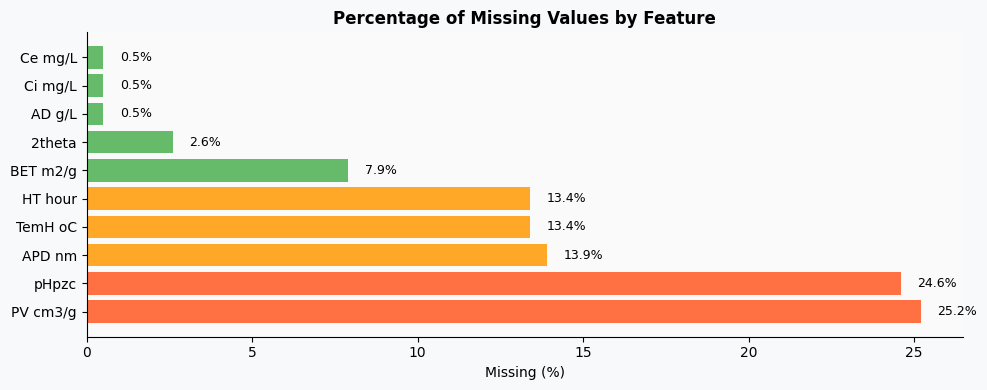

In [7]:
TARGET_COLS = ["Qe mg/g", "RR %"]
FEATURE_COLS = [col for col in df.columns.to_list() if col not in TARGET_COLS]

# Missign statistic distribution
miss = df[FEATURE_COLS].isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)

miss_df = pd.DataFrame({'Missing count': miss, 'Missing %': miss_pct})
miss_df = miss_df[miss_df['Missing count'] > 0].sort_values('Missing %', ascending=False)

# Visualize
if len(miss_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(miss_df.index, miss_df['Missing %'],
                   color=['#FF7043' if v > 20 else '#FFA726' if v > 10 else '#66BB6A'
                          for v in miss_df['Missing %']])
    ax.set_xlabel('Missing (%)')
    ax.set_title('Percentage of Missing Values by Feature')
    for bar, val in zip(bars, miss_df['Missing %']):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No missing values in all columns')

## 3. EDA – Tổng quan

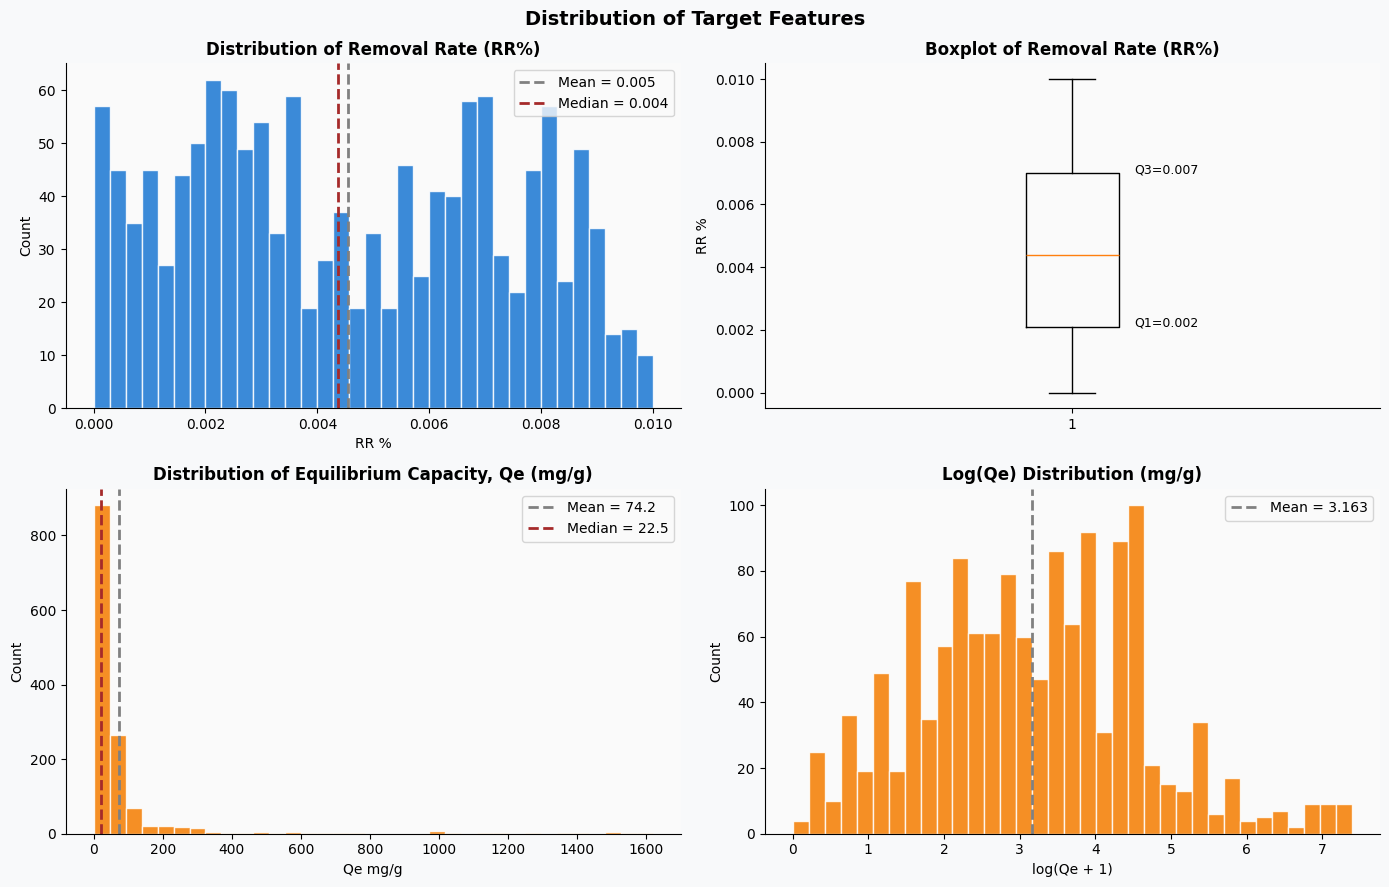

In [8]:
# Phân phối 2 biến mục tiêu
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Distribution of Target Features', fontsize=14, fontweight='bold')

# RR % – gốc
ax = axes[0, 0]
ax.hist(df['RR %'].dropna(), bins=35, color='#1976D2', edgecolor='white', alpha=0.85)
ax.axvline(df['RR %'].mean(), color='gray', ls='--', lw=2,
           label=f"Mean = {df['RR %'].mean():.3f}")
ax.axvline(df['RR %'].median(), color='brown', ls='--', lw=2,
           label=f"Median = {df['RR %'].median():.3f}")
ax.set_xlabel('RR %'); ax.set_ylabel('Count')
ax.set_title('Distribution of Removal Rate (RR%)'); ax.legend()

# RR % – boxplot
ax = axes[0, 1]
bp = ax.boxplot(df['RR %'].dropna(), vert=True, patch_artist=False)
ax.set_ylabel('RR %'); ax.set_title('Boxplot of Removal Rate (RR%)')
stats_rr = df['RR %'].describe()
ax.text(1.1, stats_rr['75%'], f"Q3={stats_rr['75%']:.3f}", fontsize=9)
ax.text(1.1, stats_rr['25%'], f"Q1={stats_rr['25%']:.3f}", fontsize=9)

# Qe – gốc (skewed)
ax = axes[1, 0]
ax.hist(df['Qe mg/g'].dropna(), bins=35, color='#F57C00', edgecolor='white', alpha=0.85)
ax.axvline(df['Qe mg/g'].mean(), color='gray', ls='--', lw=2,
           label=f"Mean = {df['Qe mg/g'].mean():.1f}")
ax.axvline(df['Qe mg/g'].median(), color='brown', ls='--', lw=2,
           label=f"Median = {df['Qe mg/g'].median():.1f}")
ax.set_xlabel('Qe mg/g'); ax.set_ylabel('Count')
ax.set_title('Distribution of Equilibrium Capacity, Qe (mg/g)'); ax.legend()

# Qe – log transform
ax = axes[1, 1]
log_qe = np.log1p(df['Qe mg/g'].dropna())
ax.hist(log_qe, bins=35, color='#F57C00', edgecolor='white', alpha=0.85)
ax.axvline(log_qe.mean(), color='gray', ls='--', lw=2,
           label=f"Mean = {log_qe.mean():.3f}")
ax.set_xlabel('log(Qe + 1)'); ax.set_ylabel('Count')
ax.set_title('Log(Qe) Distribution (mg/g)'); ax.legend()

plt.tight_layout()
plt.show()

## 4. EDA – Phân tích theo nhóm

In [9]:
# Nhóm A – Micropollutant descriptors (lặp lại theo TP, sẽ → PCA)
MICRO_COLS = ['Log Kow', 'MW g/mol', 'E', 'S', 'A', 'B', 'V']

# Nhóm B – Material texture (lặp lại theo mẻ vật liệu, sẽ → PCA)
MAT_COLS = ['BET m2/g', 'PV cm3/g', 'APD nm', 'pHpzc']

# Nhóm C – Điều kiện tổng hợp vật liệu
SYNTH_COLS = ['M(II)/(III)', 'TemH oC', 'HT hour', '2theta']

# Nhóm D – Điều kiện thí nghiệm
EXP_COLS = ['pH', 'Tem', 'Time h', 'AD g/L', 'Ci mg/L']

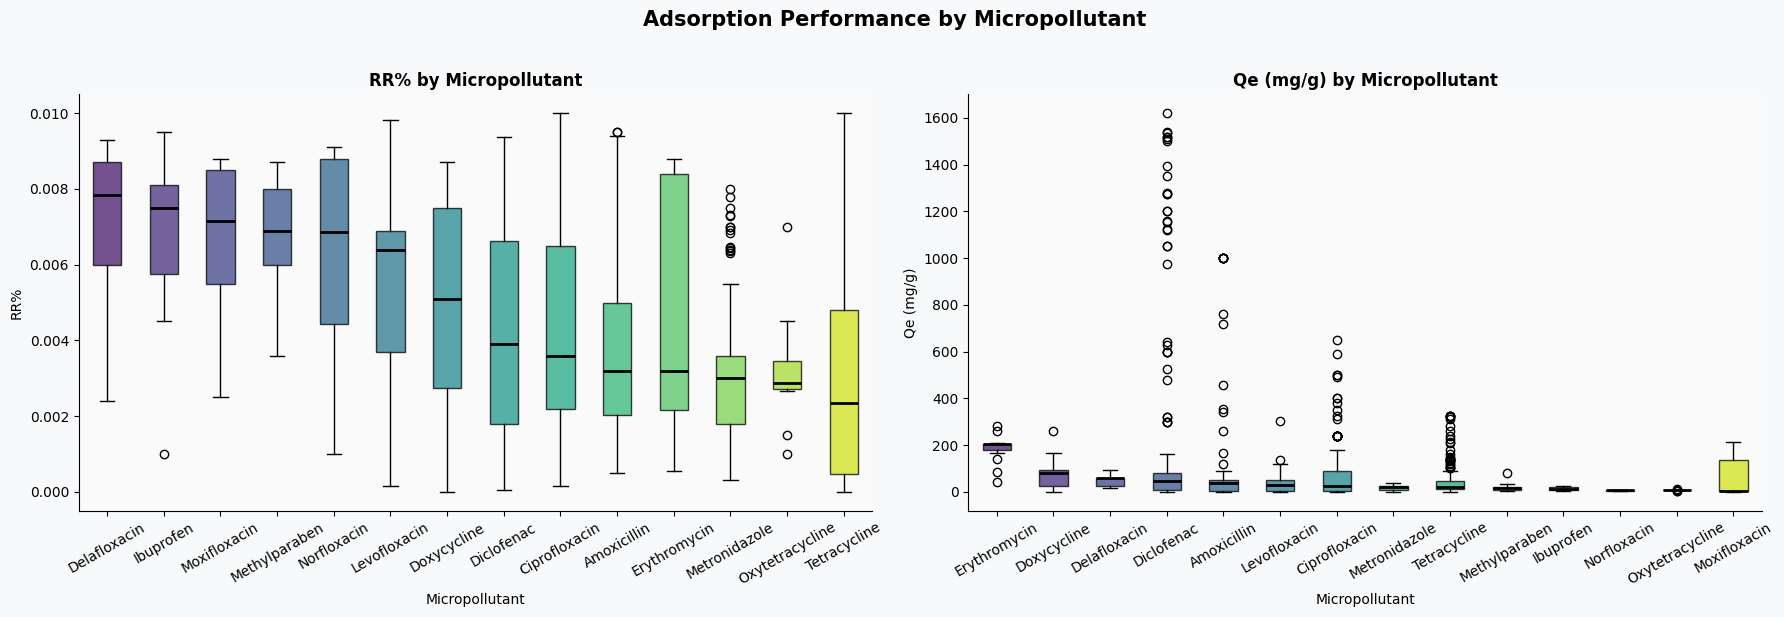

In [10]:
# RR% theo từng Micropollutant
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

order = df.groupby('TP')['RR %'].median().sort_values(ascending=False).index
palette = sns.color_palette('viridis', len(order))

ax = axes[0]
bp = ax.boxplot(
    [df[df['TP']==tp]['RR %'].dropna().values for tp in order],
    patch_artist=True, labels=order,
    medianprops=dict(color='black', lw=2)
)
for patch, c in zip(bp['boxes'], palette):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.set_ylabel('RR%'); ax.set_xlabel('Micropollutant')
ax.set_title('RR% by Micropollutant')
ax.tick_params(axis='x', rotation=30)

ax = axes[1]
order_qe = df.groupby('TP')['Qe mg/g'].median().sort_values(ascending=False).index
bp2 = ax.boxplot(
    [df[df['TP']==tp]['Qe mg/g'].dropna().values for tp in order_qe],
    patch_artist=True, labels=order_qe,
    medianprops=dict(color='black', lw=2)
)
for patch, c in zip(bp2['boxes'], palette):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.set_ylabel('Qe (mg/g)'); ax.set_xlabel('Micropollutant')
ax.set_title('Qe (mg/g) by Micropollutant')
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Adsorption Performance by Micropollutant',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

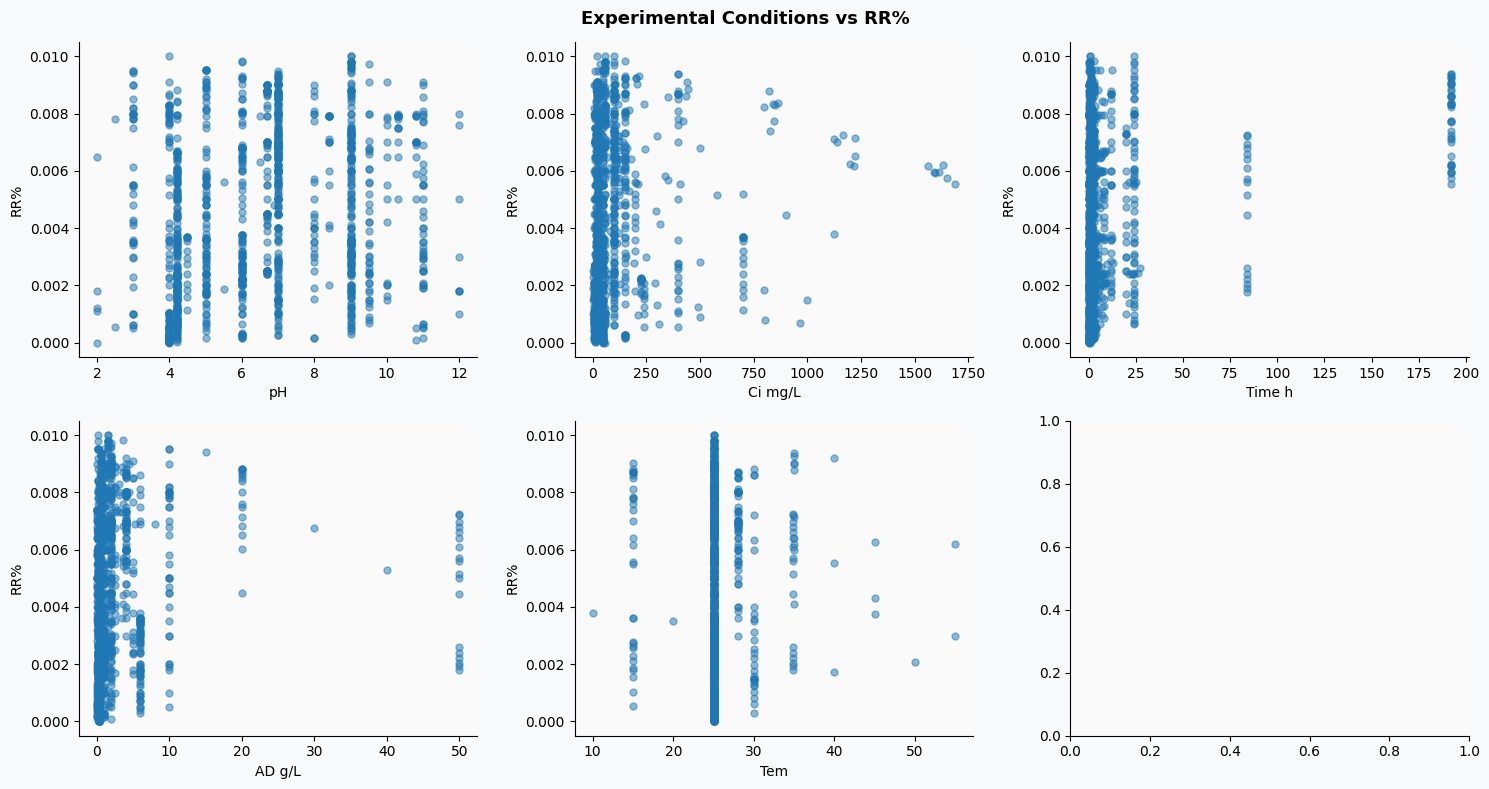

In [11]:
# Scatter: Experimental conditions vs RR%
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Experimental Conditions vs RR%', fontsize=13, fontweight='bold')
i = 0
for x_col in EXP_COLS:
    ax = axes[i % 2, i % 3]
    sub = df[[x_col, 'RR %']].dropna()
    sc = ax.scatter(sub[x_col], sub[['RR %']], alpha=0.5, s=25)
    ax.set_xlabel(x_col), ax.set_ylabel('RR%')
    i += 1
plt.tight_layout()
plt.show()

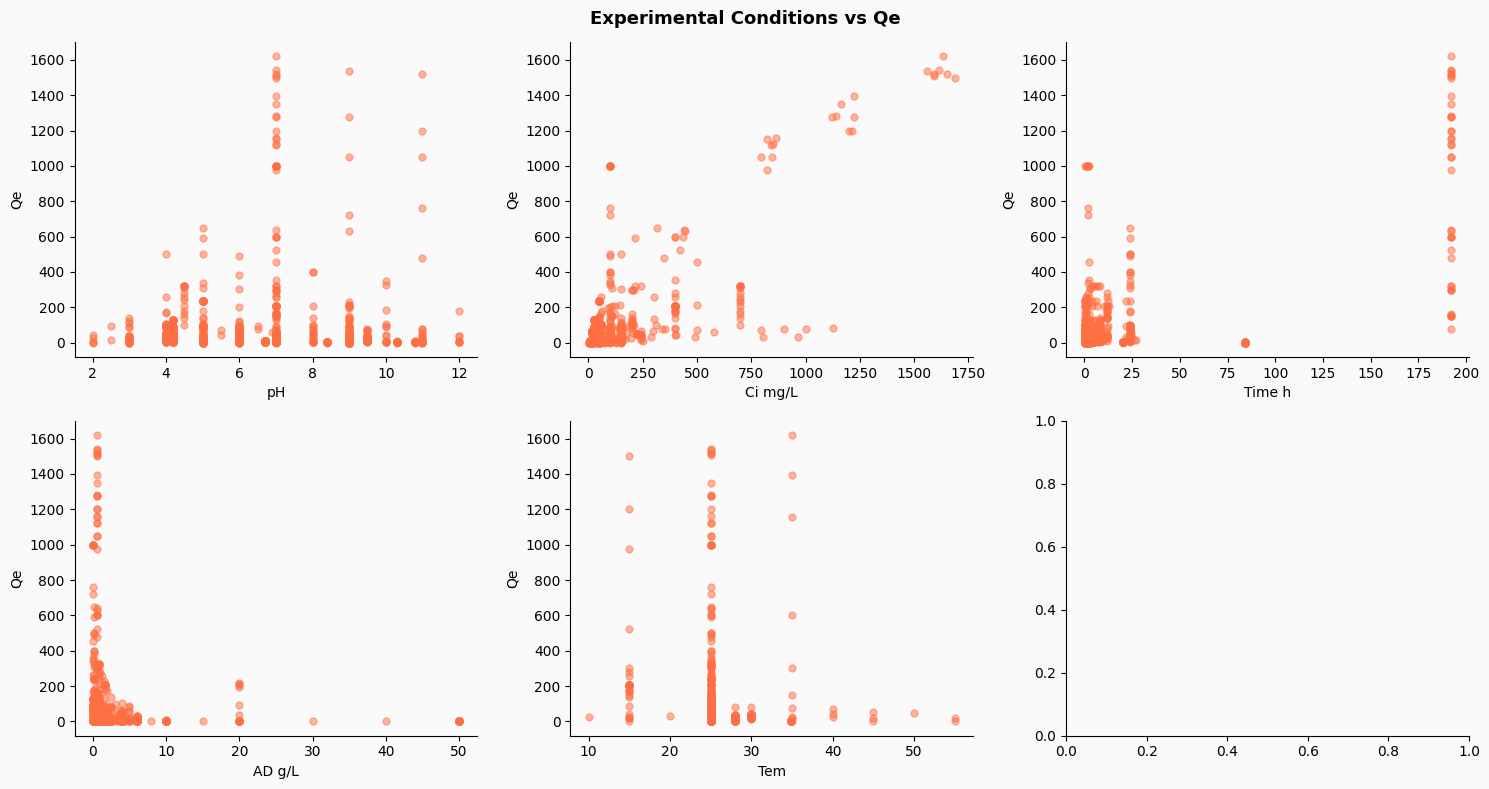

In [12]:
# Scatter: Experimental conditions vs Qe (mg/g)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Experimental Conditions vs Qe', fontsize=13, fontweight='bold')
i = 0
for x_col in EXP_COLS:
    ax = axes[i % 2, i % 3]
    sub = df[[x_col, 'Qe mg/g']].dropna()
    sc = ax.scatter(sub[x_col], sub[['Qe mg/g']], alpha=0.5, s=25, color='#FF7043')
    ax.set_xlabel(x_col), ax.set_ylabel('Qe')
    i += 1
plt.tight_layout()
plt.show()

## 5. Feature Engineering

### 5.1 KNN Imputation

In [13]:
# Delete variables less than < 0.5% and target variables
df = df.dropna(subset=["Ce mg/L", "Ci mg/L", "AD g/L", "Qe mg/g", "RR %"])
# KNN imputer cho các cột còn lại
cols_to_impute = [
    '2theta', 'BET m2/g', 'HT hour', 'TemH oC',
    'PV cm3/g', 'APD nm', 'pHpzc'
]

# Tạo một bản sao để tránh làm thay đổi dữ liệu gốc
df_imputed = df.copy()
# Chuẩn hóa dữ liệu trước khi dùng KNN
scaler = StandardScaler()
df_imputed[cols_to_impute] = scaler.fit_transform(df_imputed[cols_to_impute])

# Khởi tạo KNNImputer
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
imputed_scaled_values = knn_imputer.fit_transform(df_imputed[cols_to_impute])
# Đưa dữ liệu về lại scale ban đầu (Inverse Transform)
imputed_original_scale = scaler.inverse_transform(imputed_scaled_values)
# Gán lại mảng giá trị đã điền hoàn chỉnh vào DataFrame
df_imputed[cols_to_impute] = imputed_original_scale

print(df_imputed[cols_to_impute].isnull().sum())

2theta      0
BET m2/g    0
HT hour     0
TemH oC     0
PV cm3/g    0
APD nm      0
pHpzc       0
dtype: int64


In [14]:
cleaned_df = df.copy()
cleaned_df[cols_to_impute] = df_imputed[cols_to_impute]

### 5.2 Categorical Encoding

In [15]:
CAT_COLS = cleaned_df.select_dtypes(include=["object"]).columns.to_list()

# Label encoded categorical features
le_dict = {}
for col in CAT_COLS:
   le = LabelEncoder()
   cleaned_df[col] = le.fit_transform(cleaned_df[col])
   le_dict[col] = le

### 5.3 Highly-correlated features: Variance Inflator Factor

In [16]:
X = cleaned_df.drop(TARGET_COLS, axis=1).copy()
y = cleaned_df[TARGET_COLS].copy()

In [17]:
vif_results = {}

# Iterate over all columns in the `cleaned_df` to compute VIF for each
for feature_col in cleaned_df.columns:
    # The current `feature_col` is the dependent variable (y)
    y_vif = cleaned_df[feature_col]
    # The independent variables (X) are all other columns in `cleaned_df`,
    X_vif = cleaned_df.drop(columns=[feature_col])

    # Fit linear regression model
    linreg = LinearRegression()
    linreg.fit(X_vif, y_vif)

    # Compute R-squared
    r_squared = linreg.score(X_vif, y_vif)

    # Main VIF score
    if np.isclose(1 - r_squared, 0): # Check if difference is very close to zero
        vif_score = np.inf
    else:
        vif_score = 1 / (1 - r_squared)

    vif_results[feature_col] = vif_score

# Convert to DataFrame
vif_df = pd.DataFrame(list(vif_results.items()), columns=["Feature", "VIF"])
vif_df.sort_values(by=["VIF"], ascending=False, inplace=True)

display(vif_df)

,Feature,VIF
2,MW g/mol,86.954750
7,V,68.076233
4,S,49.730731
3,E,27.021307
22,Ci mg/L,21.569363
6,B,18.511350
15,PV cm3/g,15.657792
5,A,13.133305
23,Ce mg/L,11.679391
1,Log Kow,9.074494


👉 MW vs V? V mô tả hiệu ứng không gian trong hấp phụ xốp tốt hơn nên drop MW.

Trọng lượng phân tử (MW) và Thể tích phân tử (V) gần như có mối quan hệ tuyến tính hoàn hảo với nhau. Phân tử càng nặng thì kích thước/thể tích tự nhiên càng lớn. Việc giữ cả hai biến này trong mô hình hồi quy tuyến tính sẽ gây nhiễu trọng số nghiêm trọng.


👉 Ci mg/L vs Ce mg/L? Drop Ce để tránh target leakage


$C_e$ phụ thuộc trực tiếp vào $C_i$ và hiệu suất loại bỏ ($RR\%$) hoặc dung lượng hấp phụ ($Q_e$).


In [18]:
X = X.drop(columns=["Ce mg/L", "MW g/mol"])

### 5.3 Low-importance features: BorutaShap

By using SHAP Values as the feature selection method in BorutaShap, we get the Boruta SHAP Feature Selection Algorithm. With this approach we can get the strong addictive feature explanations existent in SHAP method while having the robustness of Boruta algorithm to ensure only significant variables remain on the set.

In [19]:
# Creates a BorutaShap selector for regression
selector = BorutaShap(importance_measure = 'shap', classification = False)
# Fits the selector for Qe mg/g
selector.fit(X = X, y = np.array(y)[:, 0], n_trials = 20, sample = False, verbose=True)
features_to_remove = selector.features_to_remove
print(features_to_remove)

  0%|          | 0/20 [00:00<?, ?it/s]

6 attributes confirmed important: ['APD nm', '2theta', 'PV cm3/g', 'Time h', 'Ci mg/L', 'AD g/L']
13 attributes confirmed unimportant: ['A', 'TemH oC', 'Log Kow', 'B', 'M(II)/(III)', 'HT hour', 'TP', 'V', 'E', 'Tem', 'Metal(III)', 'S', 'Metal(II)']
3 tentative attributes remains: ['BET m2/g', 'pHpzc', 'pH']
['TP' 'Log Kow' 'E' 'S' 'A' 'B' 'V' 'Metal(II)' 'Metal(III)' 'M(II)/(III)'
 'TemH oC' 'HT hour' 'Tem']


In [20]:
# Creates a BorutaShap selector for regression
selector = BorutaShap(importance_measure = 'shap', classification = False)
# Fits the selector for RR %
selector.fit(X = X, y = np.array(y)[:, 1], n_trials = 20, sample = False, verbose=True)
features_to_remove = selector.features_to_remove
print(features_to_remove)

  0%|          | 0/20 [00:00<?, ?it/s]

15 attributes confirmed important: ['TemH oC', 'Log Kow', 'B', 'APD nm', '2theta', 'PV cm3/g', 'pH', 'Time h', 'Ci mg/L', 'BET m2/g', 'E', 'AD g/L', 'S', 'Metal(II)', 'pHpzc']
4 attributes confirmed unimportant: ['Tem', 'A', 'HT hour', 'M(II)/(III)']
3 tentative attributes remains: ['Metal(III)', 'V', 'TP']
['A' 'M(II)/(III)' 'HT hour' 'Tem']


Tem (Temperature) và HT hour (Hydrothermal Time) đều bị thuật toán kết luận là "unimportant" cho cả hai mục tiêu.

$\rightarrow$ kết quả đo lường đã có đủ thông tin từ điều kiện tổng hợp

### 5.4 Stat Correlation

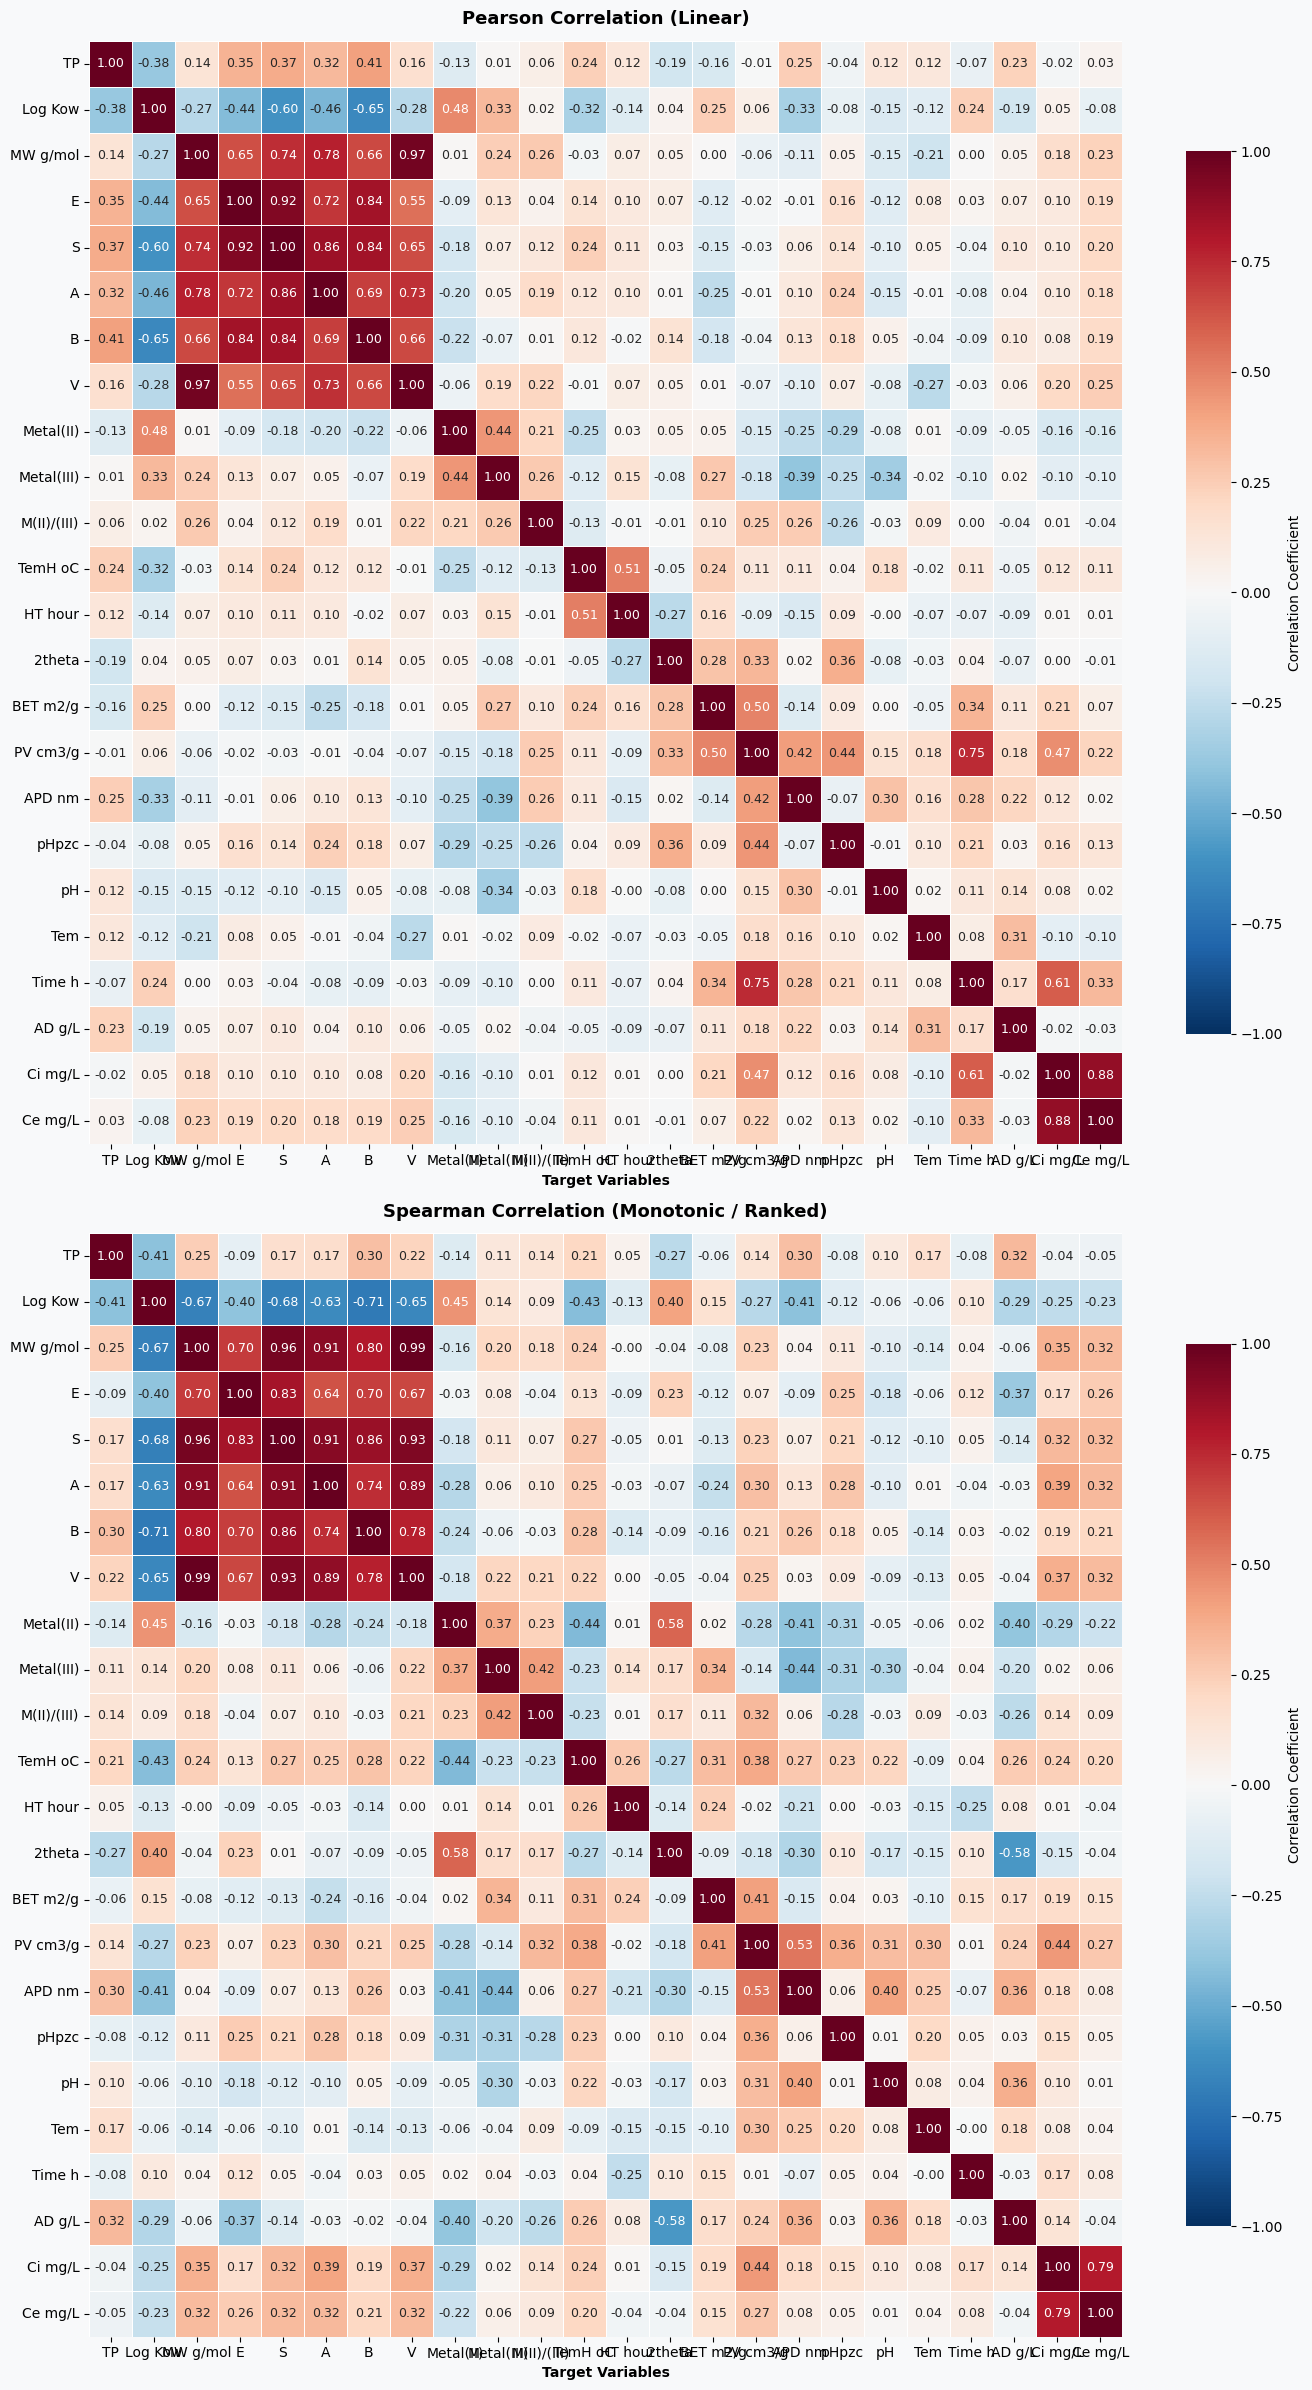

In [52]:
# Xác định targets và features
TARGETS = ["Qe mg/g", "RR %"]
NUMERIC_COLS = cleaned_df.select_dtypes(include="number").columns.to_list()
FEATURES = [col for col in NUMERIC_COLS if col not in TARGETS]

# Tính ma trận tương quan cho cả 2 method (chỉ lấy Features vs Targets)
corr_pearson = cleaned_df[NUMERIC_COLS].corr(method="pearson").loc[FEATURES, FEATURES]
corr_spearman = cleaned_df[NUMERIC_COLS].corr(method="spearman").loc[FEATURES, FEATURES]

# 3. Trực quan hóa song song 2 Heatmap
fig, axes = plt.subplots(2, 1, figsize=(14, max(6, len(FEATURES))), sharey=True)

# Common heatmap arguments
heatmap_kws = dict(
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
)

# --- Subplot 1: Pearson (Linear) ---
sns.heatmap(corr_pearson, ax=axes[0], **heatmap_kws)
axes[0].set_title(
    "Pearson Correlation (Linear)", fontsize=13, fontweight="bold", pad=12
)
axes[0].set_xlabel("Target Variables", fontweight="bold", fontsize=10)
axes[0].tick_params(axis="x", rotation=0, labelsize=10)
axes[0].tick_params(axis="y", labelsize=10)

# --- Subplot 2: Spearman (Monotonic / Ranked) ---
sns.heatmap(corr_spearman, ax=axes[1], **heatmap_kws)
axes[1].set_title(
    "Spearman Correlation (Monotonic / Ranked)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
axes[1].set_xlabel("Target Variables", fontweight="bold", fontsize=10)
axes[1].tick_params(axis="x", rotation=0, labelsize=10)
axes[1].set_ylabel("")  # Ẩn nhãn y vì đã sharey với subplot trái

plt.tight_layout()
plt.show()

###

## 6. Qe mg/g Prediction (maybe need logscaled)
* Split data 80/20 and train 5 models on 5-fold cross validation.
* Models comparison: LR, KNN, Cubist, ANN, DNN, HistGradientBoostingRegressor
* MAE (càng thấp càng tốt): HistGB ⭐ > XGBoost > Cubist > KNN > RF > ANN > LR
* R^2 (càng cao càng tốt):  HistGB ⭐ > XGBoost > Cubist > ANN > RF > KNN > LR

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from cubist import Cubist
from xgboost import XGBRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED = 42

In [34]:
# Split dataset
y_qe = np.array(y)[:, 0]
X_train, X_test, y_train, y_test = train_test_split(X, y_qe, test_size=0.2)

# Lấy số lượng biến đầu vào để thiết lập cho lớp ẩn của ANN
n_input_features = X_train.shape[1]

# Khởi tạo K-Fold với n_splits=5
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# ==========================================
# 1. THIẾT LẬP PIPELINE & GRID SEARCH
# ==========================================

# --- Linear Regresion ---
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# --- KNN (Tối ưu hóa n_neighbors từ 1 đến 10 dựa trên MAE) ---
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor())
])
knn__param_grid = {
    'regressor__n_neighbors': list(range(1, 10))
}
# scoring='neg_mean_absolute_error' để minimize MAE
knn_grid = GridSearchCV(knn_pipe, knn__param_grid, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

# --- ANN (1 lớp ẩn với ReLU, số neuron = 32) ---
ann_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', MLPRegressor(
        hidden_layer_sizes=(32,),
        activation='relu',
        solver='adam',
        max_iter=2000,
        random_state=SEED
    ))
])

# --- CUBIST (Tối ưu hóa committees và neighbors dựa trên MSE) ---
cubist_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Cubist())
])
cubist__param_grid = {
    'regressor__n_committees': list(range(1, 10)),
    'regressor__neighbors': list(range(0, 9))
}
# scoring='neg_mean_squared_error' để minimize MSE
cubist_grid = GridSearchCV(cubist_pipe, cubist__param_grid, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)

# --- Tree-based models (HistGradientBoostingRegressor and XGBoost) ---
# HistGradientBoostingRegressor
def tune_hgb_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho HistGradientBoostingRegressor"""
    print("--- Đang chạy Optuna cho HistGradientBoostingRegressor... ---")

    def objective(trial):
        params = {
            'max_iter': trial.suggest_int('max_iter', 100, 600),
            # log=True rất quan trọng để Optuna phân phối đều các giá trị nhỏ (0.0001, 0.001, 0.01)
            'learning_rate': trial.suggest_float('learning_rate', 0.0001, 1.0, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', HistGradientBoostingRegressor(**params, random_state=42))
        ])

        # Đánh giá bằng Cross Validation (trả về Negative MAE)
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    # Tạo study để Maximize vì scikit-learn trả về số âm cho các hàm lỗi (càng gần 0 càng tốt)
    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] HistGradientBoosting - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# XGBoost
def tune_xgb_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho XGBoost"""
    print("--- Đang chạy Optuna cho XGBoost... ---")

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'learning_rate': trial.suggest_float('learning_rate', 0.0001, 1.0, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_child_weight': trial.suggest_int('min_child_weight', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', XGBRegressor(**params, random_state=42, n_jobs=-1))
        ])

        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] XGBoost - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# Random Forest
def tune_rf_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho Random Forest Regressor"""
    print("--- Đang chạy Optuna cho Random Forest Regressor ... ---")

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(**params, random_state=SEED, n_jobs=-1))
        ])

        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] RandomForestRegressor - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# Chạy Optuna để lấy dict tham số (giả sử set n_trials=30 vòng cho mỗi thuật toán)
best_hgb_params = tune_hgb_optuna(X_train, y_train, cv=kf, n_trials=30)
best_xgb_params = tune_xgb_optuna(X_train, y_train, cv=kf, n_trials=30)
best_rf_params = tune_rf_optuna(X_train, y_train, cv=kf, n_trials=30)

# Tạo Pipeline mới với tham số tối ưu vừa tìm được
optimized_hgb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', HistGradientBoostingRegressor(**best_hgb_params, random_state=SEED))
])

optimized_xgb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', XGBRegressor(**best_xgb_params, random_state=SEED, n_jobs=-1))
])

optimized_rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(**best_rf_params, random_state=SEED, n_jobs=-1))
])

# ==========================================
# 2. HUẤN LUYỆN VÀ ĐÁNH GIÁ (CROSS-VALIDATION & TEST SET)
# ==========================================

def evaluate_model(model_or_grid, X_tr, y_tr, X_te, y_te, cv, model_name, is_grid=False):
    """
    Hàm huấn luyện, đánh giá K-Fold CV trên tập Train và kiểm tra trên tập Test.
    """
    print(f"--- Đang xử lý {model_name}... ---")

    # XÁC ĐỊNH MÔ HÌNH TỐI ƯU (ESTIMATOR)
    if is_grid:
        # Chạy GridSearch để tìm tham số tốt nhất
        model_or_grid.fit(X_tr, y_tr)
        best_model = model_or_grid.best_estimator_

        # In ra cấu hình tối ưu
        clean_params = {k.replace('regressor__', ''): v for k, v in model_or_grid.best_params_.items()}
        print(f"[*] Cấu hình tối ưu tìm được: {clean_params}")
    else:
        # Chạy luôn pipeline đầu vào
        best_model = model_or_grid

    # 2. ĐÁNH GIÁ K-FOLD CV TRÊN TẬP TRAIN
    # Đánh giá metrics trên model tốt nhất
    scoring = {
        'r2': 'r2',
        'neg_mae': 'neg_mean_absolute_error',
        'neg_rmse': 'neg_root_mean_squared_error',
    }

    cv_results = cross_validate(best_model, X_tr, y_tr, cv=cv, scoring=scoring, return_train_score=False)
    cv_r2_mean = np.mean(cv_results['test_r2'])
    cv_mae_mean = -np.mean(cv_results['test_neg_mae'])
    cv_rmse_mean = -np.mean(cv_results['test_neg_rmse'])

    print(f"[*] CV (Train Set) Mean R^2 : {cv_r2_mean:.4f}")
    print(f"[*] CV (Train Set) Mean MAE : {cv_mae_mean:.4f}")
    print(f"[*] CV (Train Set) Mean RMSE : {cv_rmse_mean:.4f}")

    # 3. ĐÁNH GIÁ TRÊN TẬP TEST
    # Fit lại mô hình trên dữ liệu Train
    best_model.fit(X_tr, y_tr)

    # Dự đoán và tính điểm
    y_pred = best_model.predict(X_te)
    test_r2 = r2_score(y_te, y_pred)
    test_mae = mean_absolute_error(y_te, y_pred)
    test_rmse = root_mean_squared_error(y_te, y_pred)

    print(f"Kết quả Test Set (Hold-out):")
    print(f"    Test R^2 : {test_r2:.4f}")
    print(f"    Test MAE : {test_mae:.4f}\n")
    print(f"    Test RMSE : {test_rmse:.4f}\n")

    return dict(model=best_model, y_te=y_te, y_pred=y_pred,
                r2=cv_r2_mean, mae=cv_mae_mean, label=model_name)

--- Đang chạy Optuna cho HistGradientBoostingRegressor... ---
[*] HistGradientBoosting - Tìm thấy tham số tốt nhất: {'max_iter': 514, 'learning_rate': 0.1963627954170868, 'max_depth': 15, 'min_samples_leaf': 3}
--- Đang chạy Optuna cho XGBoost... ---
[*] XGBoost - Tìm thấy tham số tốt nhất: {'n_estimators': 158, 'learning_rate': 0.4745680257510483, 'max_depth': 8, 'min_child_weight': 5}
--- Đang chạy Optuna cho Random Forest Regressor ... ---
[*] RandomForestRegressor - Tìm thấy tham số tốt nhất: {'n_estimators': 484, 'max_depth': 13, 'min_samples_leaf': 3}


In [35]:
# Gọi hàm cho các mô hình
res_qe_lr = evaluate_model(lr_pipe, X_train, y_train, X_test, y_test, cv=kf, model_name="LR", is_grid=False)
res_qe_knn = evaluate_model(knn_grid, X_train, y_train, X_test, y_test, cv=kf, model_name="KNN", is_grid=True)
res_qe_ann = evaluate_model(ann_model, X_train, y_train, X_test, y_test, cv=kf, model_name="ANN", is_grid=False)
res_qe_cubist = evaluate_model(cubist_grid, X_train, y_train, X_test, y_test, cv=kf, model_name="Cubist", is_grid=True)
res_qe_hgb = evaluate_model(optimized_hgb_model, X_train, y_train, X_test, y_test, cv=kf, model_name="HistGB", is_grid=False)
res_qe_xgb = evaluate_model(optimized_xgb_model, X_train, y_train, X_test, y_test, cv=kf, model_name="XGB", is_grid=False)
res_qe_rf = evaluate_model(optimized_rf_model, X_train, y_train, X_test, y_test, cv=kf, model_name="RF", is_grid=False)

--- Đang xử lý LR... ---
[*] CV (Train Set) Mean R^2 : 0.7766
[*] CV (Train Set) Mean MAE : 46.0112
[*] CV (Train Set) Mean RMSE : 90.5829
Kết quả Test Set (Hold-out):
    Test R^2 : 0.5002
    Test MAE : 45.3989

    Test RMSE : 109.7979

--- Đang xử lý KNN... ---
[*] Cấu hình tối ưu tìm được: {'n_neighbors': 2}
[*] CV (Train Set) Mean R^2 : 0.9305
[*] CV (Train Set) Mean MAE : 12.9438
[*] CV (Train Set) Mean RMSE : 49.2595
Kết quả Test Set (Hold-out):
    Test R^2 : 0.8814
    Test MAE : 12.7205

    Test RMSE : 53.4931

--- Đang xử lý ANN... ---
[*] CV (Train Set) Mean R^2 : 0.9039
[*] CV (Train Set) Mean MAE : 27.6084
[*] CV (Train Set) Mean RMSE : 59.8717
Kết quả Test Set (Hold-out):
    Test R^2 : 0.7541
    Test MAE : 29.5649

    Test RMSE : 77.0215

--- Đang xử lý Cubist... ---
[*] Cấu hình tối ưu tìm được: {'n_committees': 7, 'neighbors': 1}
[*] CV (Train Set) Mean R^2 : 0.9363
[*] CV (Train Set) Mean MAE : 11.7025
[*] CV (Train Set) Mean RMSE : 47.4482
Kết quả Test Set (Hold

## 7. RR % Prediction
* Split data 80/20 and train 5 models on 5-fold cross validation.
* Models comparison: LR, KNN, Cubist, ANN, DNN, HistGradientBoostingRegressor
* MAE (càng thấp càng tốt): HistGB ⭐ > KNN > XGB > RF > Cubist > LR > ANN
* R^2 (càng cao càng tốt): HistGB ⭐> XGB > RF > KNN > Cubist >LR > ANN

In [36]:
# Split dataset
y_rr = np.array(y)[:, 1]
X_train, X_test, y_train, y_test = train_test_split(X, y_rr, test_size=0.2)

# Lấy số lượng biến đầu vào để thiết lập cho lớp ẩn của ANN
n_input_features = X_train.shape[1]

# Khởi tạo K-Fold với n_splits=5
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# ==========================================
# 1. THIẾT LẬP PIPELINE & GRID SEARCH
# ==========================================

# --- Linear Regression ---
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# --- KNN (Tối ưu hóa n_neighbors từ 1 đến 10 dựa trên MAE) ---
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor())
])
knn__param_grid = {
    'regressor__n_neighbors': list(range(1, 10))
}
# scoring='neg_mean_absolute_error' để minimize MAE
knn_grid = GridSearchCV(knn_pipe, knn__param_grid, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

# --- ANN (1 lớp ẩn với ReLU, số neuron = 32) ---
ann_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', MLPRegressor(
        hidden_layer_sizes=(32,),
        activation='relu',
        solver='adam',
        max_iter=2000,
        random_state=SEED
    ))
])

# --- CUBIST (Tối ưu hóa committees và neighbors dựa trên MSE) ---
cubist_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Cubist())
])
cubist__param_grid = {
    'regressor__n_committees': list(range(1, 10)),
    'regressor__neighbors': list(range(0, 9))
}
# scoring='neg_mean_squared_error' để minimize MSE
cubist_grid = GridSearchCV(cubist_pipe, cubist__param_grid, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)

# --- Tree-based models (HistGradientBoostingRegressor and XGBoost) ---
# HistGradientBoostingRegressor
def tune_hgb_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho HistGradientBoostingRegressor"""
    print("--- Đang chạy Optuna cho HistGradientBoostingRegressor... ---")

    def objective(trial):
        params = {
            'max_iter': trial.suggest_int('max_iter', 100, 600),
            # log=True rất quan trọng để Optuna phân phối đều các giá trị nhỏ (0.0001, 0.001, 0.01)
            'learning_rate': trial.suggest_float('learning_rate', 0.0001, 1.0, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', HistGradientBoostingRegressor(**params, random_state=42))
        ])

        # Đánh giá bằng Cross Validation (trả về Negative MAE)
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    # Tạo study để Maximize vì scikit-learn trả về số âm cho các hàm lỗi (càng gần 0 càng tốt)
    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] HistGradientBoosting - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# XGBoost
def tune_xgb_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho XGBoost"""
    print("--- Đang chạy Optuna cho XGBoost... ---")

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'learning_rate': trial.suggest_float('learning_rate', 0.0001, 1.0, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_child_weight': trial.suggest_int('min_child_weight', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', XGBRegressor(**params, random_state=42, n_jobs=-1))
        ])

        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] XGBoost - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# Random Forest
def tune_rf_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho Random Forest Regressor"""
    print("--- Đang chạy Optuna cho Random Forest Regressor ... ---")

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(**params, random_state=SEED, n_jobs=-1))
        ])

        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] RandomForestRegressor - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# Chạy Optuna để lấy dict tham số (giả sử set n_trials=30 vòng cho mỗi thuật toán)
best_hgb_params = tune_hgb_optuna(X_train, y_train, cv=kf, n_trials=30)
best_xgb_params = tune_xgb_optuna(X_train, y_train, cv=kf, n_trials=30)
best_rf_params = tune_rf_optuna(X_train, y_train, cv=kf, n_trials=30)

# Tạo Pipeline mới với tham số tối ưu vừa tìm được
optimized_hgb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', HistGradientBoostingRegressor(**best_hgb_params, random_state=SEED))
])

optimized_xgb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', XGBRegressor(**best_xgb_params, random_state=SEED, n_jobs=-1))
])

optimized_rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(**best_rf_params, random_state=SEED, n_jobs=-1))
])

# ==========================================
# 2. HUẤN LUYỆN VÀ ĐÁNH GIÁ (CROSS-VALIDATION & TEST SET)
# ==========================================

def evaluate_model(model_or_grid, X_tr, y_tr, X_te, y_te, cv, model_name, is_grid=False):
    """
    Hàm huấn luyện, đánh giá K-Fold CV trên tập Train và kiểm tra trên tập Test.
    """
    print(f"--- Đang xử lý {model_name}... ---")

    # XÁC ĐỊNH MÔ HÌNH TỐI ƯU (ESTIMATOR)
    if is_grid:
        # Chạy GridSearch để tìm tham số tốt nhất
        model_or_grid.fit(X_tr, y_tr)
        best_model = model_or_grid.best_estimator_

        # In ra cấu hình tối ưu
        clean_params = {k.replace('regressor__', ''): v for k, v in model_or_grid.best_params_.items()}
        print(f"[*] Cấu hình tối ưu tìm được: {clean_params}")
    else:
        # Chạy luôn pipeline đầu vào
        best_model = model_or_grid

    # 2. ĐÁNH GIÁ K-FOLD CV TRÊN TẬP TRAIN
    # Đánh giá metrics trên model tốt nhất
    scoring = {
        'r2': 'r2',
        'neg_mae': 'neg_mean_absolute_error',
        'neg_rmse': 'neg_root_mean_squared_error',
    }

    cv_results = cross_validate(best_model, X_tr, y_tr, cv=cv, scoring=scoring, return_train_score=False)
    cv_r2_mean = np.mean(cv_results['test_r2'])
    cv_mae_mean = -np.mean(cv_results['test_neg_mae'])
    cv_rmse_mean = -np.mean(cv_results['test_neg_rmse'])

    print(f"[*] CV (Train Set) Mean R^2 : {cv_r2_mean:.4f}")
    print(f"[*] CV (Train Set) Mean MAE : {cv_mae_mean:.4f}")
    print(f"[*] CV (Train Set) Mean RMSE : {cv_rmse_mean:.4f}")

    # 3. ĐÁNH GIÁ TRÊN TẬP TEST
    # Fit lại mô hình trên dữ liệu Train
    best_model.fit(X_tr, y_tr)

    # Dự đoán và tính điểm
    y_pred = best_model.predict(X_te)
    test_r2 = r2_score(y_te, y_pred)
    test_mae = mean_absolute_error(y_te, y_pred)
    test_rmse = root_mean_squared_error(y_te, y_pred)

    print(f"Kết quả Test Set (Hold-out):")
    print(f"    Test R^2 : {test_r2:.4f}")
    print(f"    Test MAE : {test_mae:.4f}\n")
    print(f"    Test RMSE : {test_rmse:.4f}\n")

    return dict(model=best_model, y_te=y_te, y_pred=y_pred,
                r2=cv_r2_mean, mae=cv_mae_mean, label=model_name)

--- Đang chạy Optuna cho HistGradientBoostingRegressor... ---
[*] HistGradientBoosting - Tìm thấy tham số tốt nhất: {'max_iter': 536, 'learning_rate': 0.30492104010815196, 'max_depth': 13, 'min_samples_leaf': 5}
--- Đang chạy Optuna cho XGBoost... ---
[*] XGBoost - Tìm thấy tham số tốt nhất: {'n_estimators': 172, 'learning_rate': 0.24055320335780997, 'max_depth': 13, 'min_child_weight': 6}
--- Đang chạy Optuna cho Random Forest Regressor ... ---
[*] RandomForestRegressor - Tìm thấy tham số tốt nhất: {'n_estimators': 376, 'max_depth': 13, 'min_samples_leaf': 3}


In [37]:
# Gọi hàm cho các mô hình
res_rr_lr = evaluate_model(lr_pipe, X_train, y_train, X_test, y_test, cv=kf, model_name="LR", is_grid=False)
res_rr_knn = evaluate_model(knn_grid, X_train, y_train, X_test, y_test, cv=kf, model_name="KNN", is_grid=True)
res_rr_ann = evaluate_model(ann_model, X_train, y_train, X_test, y_test, cv=kf, model_name="ANN", is_grid=False)
res_rr_cubist = evaluate_model(cubist_grid, X_train, y_train, X_test, y_test, cv=kf, model_name="Cubist", is_grid=True)
res_rr_hgb = evaluate_model(optimized_hgb_model, X_train, y_train, X_test, y_test, cv=kf, model_name="HistGB", is_grid=False)
res_rr_xgb = evaluate_model(optimized_xgb_model, X_train, y_train, X_test, y_test, cv=kf, model_name="XGB", is_grid=False)
res_rr_rf = evaluate_model(optimized_rf_model, X_train, y_train, X_test, y_test, cv=kf, model_name="RF", is_grid=False)

--- Đang xử lý LR... ---
[*] CV (Train Set) Mean R^2 : 0.2591
[*] CV (Train Set) Mean MAE : 0.0020
[*] CV (Train Set) Mean RMSE : 0.0024
Kết quả Test Set (Hold-out):
    Test R^2 : 0.3526
    Test MAE : 0.0019

    Test RMSE : 0.0022

--- Đang xử lý KNN... ---
[*] Cấu hình tối ưu tìm được: {'n_neighbors': 1}
[*] CV (Train Set) Mean R^2 : 0.7476
[*] CV (Train Set) Mean MAE : 0.0008
[*] CV (Train Set) Mean RMSE : 0.0014
Kết quả Test Set (Hold-out):
    Test R^2 : 0.7696
    Test MAE : 0.0007

    Test RMSE : 0.0013

--- Đang xử lý ANN... ---
[*] CV (Train Set) Mean R^2 : -643.0160
[*] CV (Train Set) Mean MAE : 0.0416
[*] CV (Train Set) Mean RMSE : 0.0698
Kết quả Test Set (Hold-out):
    Test R^2 : -494.4964
    Test MAE : 0.0334

    Test RMSE : 0.0621

--- Đang xử lý Cubist... ---
[*] Cấu hình tối ưu tìm được: {'n_committees': 9, 'neighbors': 1}
[*] CV (Train Set) Mean R^2 : 0.7087
[*] CV (Train Set) Mean MAE : 0.0010
[*] CV (Train Set) Mean RMSE : 0.0015
Kết quả Test Set (Hold-out):
  

## 8. Best performance viz

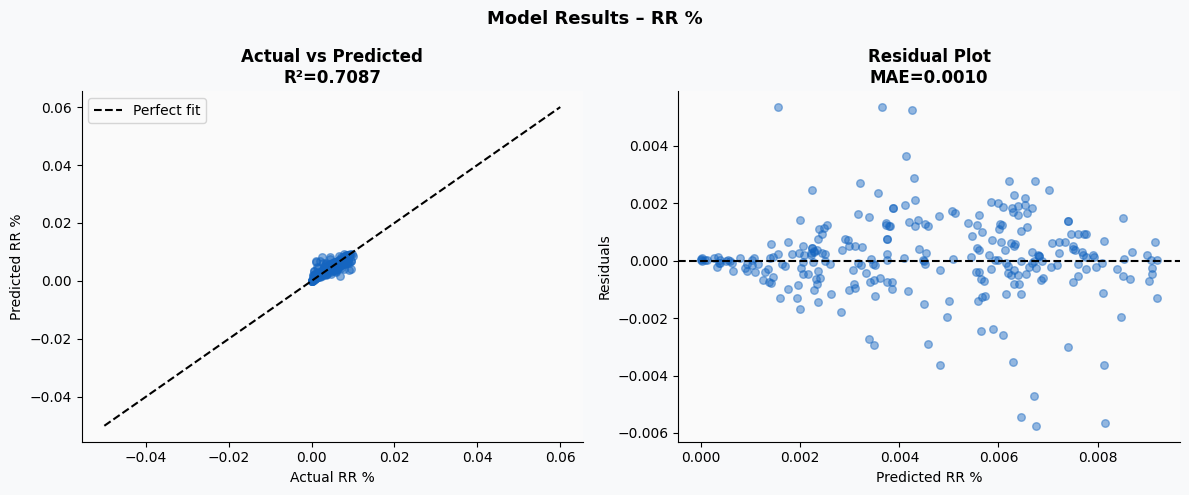

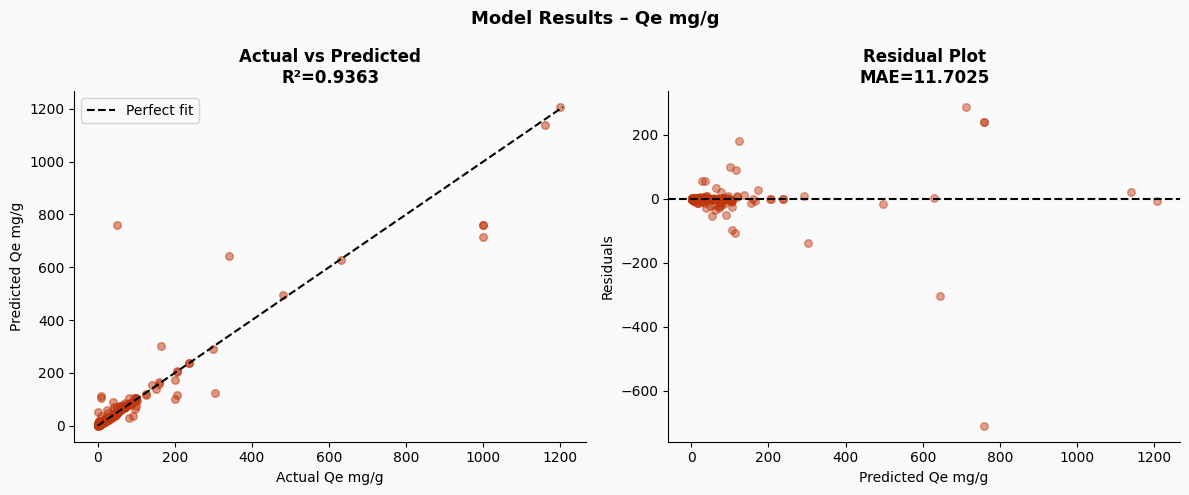

In [38]:
label = ['RR %', 'Qe mg/g']

i = 0
for res in res_rr_cubist, res_qe_cubist:
    # Manual label
    y_t, y_p = res['y_te'], res['y_pred']
    color = '#1565C0' if 'RR' in label[i] else '#BF360C'

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Model Results – {label[i]}', fontsize=13, fontweight='bold')

    # Actual vs Predicted
    ax = axes[0]
    ax.scatter(y_t, y_p, alpha=0.5, s=30, color=color)
    lo, hi = min(y_t.min(), y_p.min())-0.05, max(y_t.max(), y_p.max())+0.05
    ax.plot([lo,hi],[lo,hi],'k--',lw=1.5,label='Perfect fit')
    ax.set_xlabel(f'Actual {label[i]}'); ax.set_ylabel(f'Predicted {label[i]}')
    ax.set_title(f'Actual vs Predicted\nR²={res["r2"]:.4f}')
    ax.legend()

    # Residuals
    ax = axes[1]
    residuals = y_t - y_p
    ax.scatter(y_p, residuals, alpha=0.45, s=30, color=color)
    ax.axhline(0, color='black', ls='--', lw=1.5)
    ax.set_xlabel(f'Predicted {label[i]}'); ax.set_ylabel('Residuals')
    ax.set_title(f'Residual Plot\nMAE={res["mae"]:.4f}')

    plt.tight_layout()
    plt.show()

    # Change label
    td = 'RR %' if 'RR' in label[i] else 'Qe (mg/g)'

    i += 1

## 9. Permutation Importance – Tổng hợp & So sánh
* Permutation Importance for LR, XGB, RF, HistGB, Cubist

$\rightarrow$ Linear Regression as the most robust to noise


### Qe (mg/g)

In [39]:
from sklearn.inspection import permutation_importance

In [40]:
def extract_feature_ranks(model, feature_names, regressor_type, X_df=None, y_df=None):
    """
    Hàm trích xuất và xếp hạng độ quan trọng của biến từ các loại mô hình khác nhau.
    Rank 1 = Quan trọng nhất.
    """
    # Assuming 'model' is a Pipeline, extract the regressor estimator
    regressor_estimator = model.named_steps['regressor']

    if regressor_type == 'LR':
        # Đối với Linear Regression, độ quan trọng = giá trị tuyệt đối của hệ số (do data đã scale)
        importances = np.abs(regressor_estimator.coef_)

    elif regressor_type in ['XGB', 'RF']:
        # XGBoost và Random Forest dùng thuộc tính feature_importances_
        importances = regressor_estimator.feature_importances_

    elif regressor_type == 'HistGB':
        result = permutation_importance(model, X_df, y_df, n_repeats=10, random_state=SEED, n_jobs=-1)
        importances = result.importances_mean

    elif regressor_type == 'Cubist':
        # Cubist trả về DataFrame. Ta dùng tỷ lệ xuất hiện trong phương trình hồi quy (Model)
        cubist_imp = regressor_estimator.feature_importances_
        # Chuyển đổi thành mảng theo đúng thứ tự cột của X
        importances = np.zeros(len(feature_names))
        for idx, col in enumerate(feature_names):
            if col in cubist_imp.index:
                importances[idx] = cubist_imp.loc[col, 'Model']

    # Chuyển importances thành DataFrame để dễ xếp hạng (Ranking)
    df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    # Xếp hạng: Giá trị lớn nhất -> Rank 1
    df_imp['Rank'] = df_imp['Importance'].rank(ascending=False, method='min')
    return df_imp.set_index('Feature')['Rank'].to_dict()


def evaluate_feature_importance_methods(X, y, base_models):
    """
    Tiêm nhiễu với các scale khác nhau và theo dõi thứ hạng của biến 'random'.
    """
    scales = [0.001, 10, 1000]
    results = []

    for scale in scales:
        print(f"--- Đang kiểm thử với Noise Scale: {scale} ---")

        # 1. Tạo tập X_train_noisy bằng cách thêm biến 'random'
        X_noisy = X.copy()
        # Standardize data
        sc = StandardScaler()
        X_scaled = sc.fit_transform(X)
        # Tạo dữ liệu ngẫu nhiên phân phối chuẩn, sau đó nhân với scale
        np.random.seed(42)
        X_noisy['random_noise'] = np.random.randn(len(X)) * scale

        features_noisy = X_noisy.columns.tolist()

        # 2. Huấn luyện và trích xuất thứ hạng cho từng mô hình
        for model_name, model_info in base_models.items():
            regressor = model_info['model']
            m_type = model_info['type']

            # Khởi tạo Pipeline mới để tránh ghi đè model cũ
            import copy
            test_regressor = copy.deepcopy(regressor)

            # Huấn luyện trên tập dữ liệu đã có nhiễu
            test_regressor.fit(X_noisy, y)

            # Trích xuất xếp hạng - Pass test_regressor instead of regressor
            ranks = extract_feature_ranks(test_regressor, features_noisy, m_type)

            # Lưu lại kết quả thứ hạng của riêng biến 'random_noise'
            # (Tổng số biến lúc này là 23, do đó rank tối đa là 23)
            noise_rank = ranks['random_noise']

            results.append({
                'Model': model_name,
                'Noise Scale': scale,
                'Noise Rank': noise_rank
            })

    # Chuyển kết quả thành DataFrame để dễ nhìn
    results_df = pd.DataFrame(results)
    pivot_results = results_df.pivot(index='Model', columns='Noise Scale', values='Noise Rank')

    print("\n[ KẾT QUẢ ] Thứ hạng của biến nhiễu 'random_noise' (Rank 1 là quan trọng nhất, Rank 23 là kém nhất)")
    print(pivot_results)
    return pivot_results

In [41]:
def extract_feature_ranks(model, feature_names, X_df, y_df):
    """
    Hàm trích xuất và xếp hạng độ quan trọng của biến từ các loại mô hình khác nhau.
    Rank 1 = Quan trọng nhất.
    """
    # Assuming 'model' is a Pipeline, extract the regressor estimator
    regressor_estimator = model.named_steps['regressor']
    # Permute features to compute importances
    result = permutation_importance(model, X_df, y_df, n_repeats=10, random_state=SEED, n_jobs=-1)
    importances = result.importances_mean
    # Chuyển importances thành DataFrame để dễ xếp hạng (Ranking)
    df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

    # Xếp hạng: Giá trị lớn nhất -> Rank 1
    df_imp['Rank'] = df_imp['Importance'].rank(ascending=False, method='min')

    return df_imp.set_index('Feature')['Rank'].to_dict()


def evaluate_feature_importance_methods(X, y, base_models):
    """
    Tiêm nhiễu với các scale khác nhau và theo dõi thứ hạng của biến 'random'.
    """
    scales = [0.001, 10, 1000]
    results = []

    for scale in scales:
        print(f"--- Đang kiểm thử với Noise Scale: {scale} ---")

        # 1. Tạo tập X_train_noisy bằng cách thêm biến 'random'
        X_noisy = X.copy()
        # Standardize data
        sc = StandardScaler()
        X_scaled = sc.fit_transform(X)
        # Tạo dữ liệu ngẫu nhiên phân phối chuẩn, sau đó nhân với scale
        np.random.seed(42)
        X_noisy['random_noise'] = np.random.randn(len(X)) * scale

        features_noisy = X_noisy.columns.tolist()

        # 2. Huấn luyện và trích xuất thứ hạng cho từng mô hình
        for model_name, model_info in base_models.items():
            regressor = model_info['model']

            # Khởi tạo Pipeline mới để tránh ghi đè model cũ
            import copy
            test_regressor = copy.deepcopy(regressor)

            # Huấn luyện trên tập dữ liệu đã có nhiễu
            test_regressor.fit(X_noisy, y)

            # Trích xuất xếp hạng - Pass test_regressor instead of regressor
            ranks = extract_feature_ranks(test_regressor, features_noisy, X_noisy, y)

            # Lưu lại kết quả thứ hạng của riêng biến 'random_noise'
            # (Tổng số biến lúc này là 23, do đó rank tối đa là 23)
            noise_rank = ranks['random_noise']

            results.append({
                'Model': model_name,
                'Noise Scale': scale,
                'Noise Rank': noise_rank
            })

    # Chuyển kết quả thành DataFrame để dễ nhìn
    results_df = pd.DataFrame(results)
    pivot_results = results_df.pivot(index='Model', columns='Noise Scale', values='Noise Rank')

    print("\n[ KẾT QUẢ ] Thứ hạng của biến nhiễu 'random_noise' (Rank 1 là quan trọng nhất, Rank 23 là kém nhất)")
    print(pivot_results)
    return pivot_results

In [43]:
# Khai báo dictionary chứa các mô hình cần đánh giá
models_to_test_qe = {
    'Linear Regression': {
        'model': res_qe_lr["model"],
        'type': 'LR'
    },
    'HistGradientBoosting': {
        'model': res_qe_hgb["model"],
        'type': 'XGB'
    },
    'Random Forest': {
        'model': res_qe_rf["model"],
        'type': 'RF'
    },
    'XGBoost': {
        'model': res_qe_xgb["model"],
        'type': 'XGB'
    },
    'Cubist': {
        'model': res_qe_cubist["model"],
        'type': 'Cubist'
    }
}

# Chạy thử nghiệm
pivot_table_qe = evaluate_feature_importance_methods(X, y_qe, models_to_test_qe)

--- Đang kiểm thử với Noise Scale: 0.001 ---
--- Đang kiểm thử với Noise Scale: 10 ---
--- Đang kiểm thử với Noise Scale: 1000 ---

[ KẾT QUẢ ] Thứ hạng của biến nhiễu 'random_noise' (Rank 1 là quan trọng nhất, Rank 23 là kém nhất)
Noise Scale           0.001     10.000    1000.000
Model                                             
Cubist                     7.0       7.0       7.0
HistGradientBoosting       8.0       8.0       8.0
Linear Regression         18.0      18.0      18.0
Random Forest              5.0       5.0       5.0
XGBoost                    6.0       6.0       6.0


Chọn Linear Regression cho Permutation Importance

In [44]:
lr_rank_qe = extract_feature_ranks(res_qe_lr["model"], X.columns.to_list(), X, y_qe)
rank_df_qe = pd.Series(lr_rank_qe).to_frame(name='Rank').sort_values(by="Rank")
print(rank_df_qe)

             Rank
Ci mg/L       1.0
Time h        2.0
B             3.0
E             4.0
2theta        5.0
Log Kow       6.0
AD g/L        7.0
S             8.0
PV cm3/g      9.0
V            10.0
Metal(II)    11.0
HT hour      12.0
TP           13.0
BET m2/g     14.0
Tem          15.0
pHpzc        16.0
TemH oC      17.0
pH           18.0
M(II)/(III)  19.0
Metal(III)   20.0
A            21.0
APD nm       22.0


SHAP Feature Importance

In [45]:
import shap

PermutationExplainer explainer: 269it [12:44,  2.85s/it]


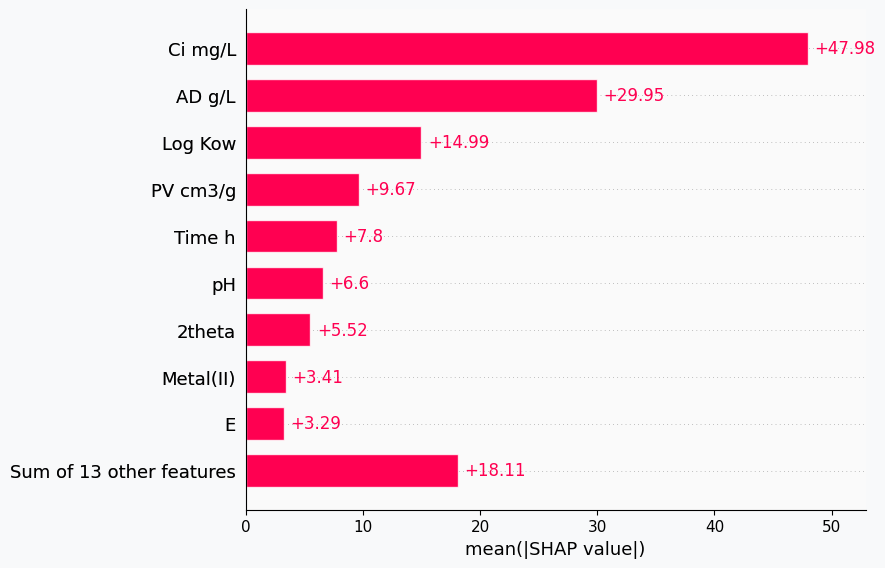

In [47]:
# Create a background dataset from X_train (100-200 rows is optimal for speed)
background_data = shap.sample(X_train, 100)

# Pass the .predict method explicitly for regression models
explainer_qe_hgb = shap.Explainer(res_qe_hgb["model"].predict, background_data)

# Compute SHAP values strictly on the test set (or a subset of test set)
shap_values_qe = explainer_qe_hgb(X_test)

# 4. Visualize standard global feature importance (mean |SHAP value|)
shap.plots.bar(shap_values_qe)

### RR%

In [48]:
# Khai báo dictionary chứa các mô hình cần đánh giá
models_to_test_rr = {
    'Linear Regression': {
        'model': res_rr_lr["model"],
        'type': 'LR'
    },
    'HistGradientBoosting': {
        'model': res_rr_hgb["model"],
        'type': 'XGB'
    },
    'Random Forest': {
        'model': res_rr_rf["model"],
        'type': 'RF'
    },
    'XGBoost': {
        'model': res_rr_xgb["model"],
        'type': 'XGB'
    },
    'Cubist': {
        'model': res_rr_cubist["model"],
        'type': 'Cubist'
    }
}

# Chạy thử nghiệm
pivot_table_rr = evaluate_feature_importance_methods(X, y_rr, models_to_test_rr)

--- Đang kiểm thử với Noise Scale: 0.001 ---
--- Đang kiểm thử với Noise Scale: 10 ---
--- Đang kiểm thử với Noise Scale: 1000 ---

[ KẾT QUẢ ] Thứ hạng của biến nhiễu 'random_noise' (Rank 1 là quan trọng nhất, Rank 23 là kém nhất)
Noise Scale           0.001     10.000    1000.000
Model                                             
Cubist                     2.0       2.0       2.0
HistGradientBoosting       9.0       9.0       9.0
Linear Regression         22.0      22.0      22.0
Random Forest             13.0      13.0      13.0
XGBoost                   13.0      13.0      13.0


In [49]:
lr_rank_rr = extract_feature_ranks(res_rr_lr["model"], X.columns.to_list(), X, y_rr)
rank_df_rr = pd.Series(lr_rank_rr).to_frame(name='Rank').sort_values(by="Rank")
print(rank_df_rr)

             Rank
Time h        1.0
S             2.0
TemH oC       3.0
A             4.0
PV cm3/g      5.0
Log Kow       6.0
E             7.0
BET m2/g      8.0
pH            9.0
HT hour      10.0
2theta       11.0
M(II)/(III)  12.0
Metal(III)   13.0
TP           14.0
pHpzc        15.0
B            16.0
Ci mg/L      17.0
Metal(II)    18.0
AD g/L       19.0
V            20.0
Tem          21.0
APD nm       22.0


PermutationExplainer explainer: 269it [13:03,  2.96s/it]


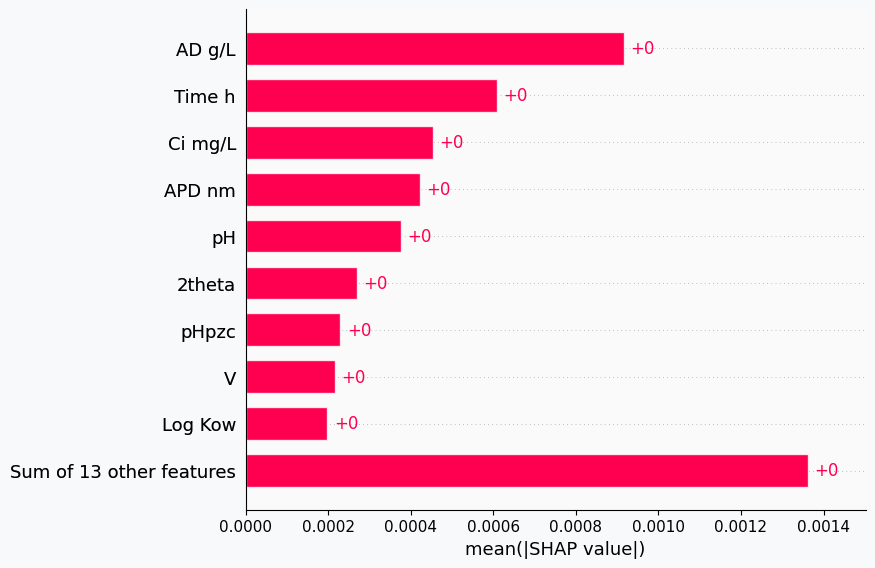

In [53]:
# Create a background dataset from X_train (100-200 rows is optimal for speed)
background_data = shap.sample(X_train, 100)

# Pass the .predict method explicitly for regression models
explainer_rr_hgb = shap.Explainer(res_rr_hgb["model"].predict, background_data)

# Compute SHAP values strictly on the test set (or a subset of test set)
shap_values_rr = explainer_rr_hgb(X_test)

# 4. Visualize standard global feature importance (mean |SHAP value|)
shap.plots.bar(shap_values_rr)